# Data preprocessing

In [1]:
#loading packages
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install sci-kit learn
!pip install seaborn
!pip install scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

In [3]:
#loading and checking data
df = pd.read_csv('/Users/aamirdevnath/Documents/Skills Development/Portfolio Projects/Data analysis project #4/bike_share_data.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1/1/2011 0:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,1/1/2011 1:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,1/1/2011 2:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,1/1/2011 3:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,1/1/2011 4:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
#prepare data by creating a month, year, and total rider column
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.strftime('%B')
df['year'] = df.datetime.dt.year
df['month_num'] = df['datetime'].dt.month
df['day number'] = df['datetime'].dt.dayofweek
df['day of week'] = df ['datetime'].dt.strftime('%A')
df['total riders'] = df['casual'] + df['registered']
df['hour'] = df['datetime'].dt.hour
df.head ()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,year,month_num,day number,day of week,total riders,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,January,2011,1,5,Saturday,16,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,January,2011,1,5,Saturday,40,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,January,2011,1,5,Saturday,32,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,January,2011,1,5,Saturday,13,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,January,2011,1,5,Saturday,1,4


In [5]:
#mapping season dictionary to the season numerical column
seasons_mapping = {1: 'winter',
                   2: 'spring', 
                   3: 'summer',
                   4: 'autumn'}
df['season'] = df['season'].map(seasons_mapping)
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,year,month_num,day number,day of week,total riders,hour
0,2011-01-01 00:00:00,winter,0,0,1,9.84,14.395,81,0.0,3,13,16,January,2011,1,5,Saturday,16,0
1,2011-01-01 01:00:00,winter,0,0,1,9.02,13.635,80,0.0,8,32,40,January,2011,1,5,Saturday,40,1
2,2011-01-01 02:00:00,winter,0,0,1,9.02,13.635,80,0.0,5,27,32,January,2011,1,5,Saturday,32,2
3,2011-01-01 03:00:00,winter,0,0,1,9.84,14.395,75,0.0,3,10,13,January,2011,1,5,Saturday,13,3
4,2011-01-01 04:00:00,winter,0,0,1,9.84,14.395,75,0.0,0,1,1,January,2011,1,5,Saturday,1,4


In [6]:
#what percent of riders are registered?
df['registered'].sum()/df['total riders'].sum()

np.float64(0.811968586548107)

In [7]:
#does the registered rider percentage increase over time?
df.groupby(['season', 'month'])['registered'].sum()/df.groupby('month')['total riders'].sum()

season  month    
autumn  December     0.908217
        November     0.856308
        October      0.816390
spring  April        0.762171
        June         0.779942
        May          0.793727
summer  August       0.785168
        July         0.762614
        September    0.784025
winter  February     0.906198
        January      0.909218
        March        0.812316
dtype: float64

In [8]:
#what is the percentage of casual riders by month?
df.groupby('month')['total riders'].sum()/df['total riders'].sum()*100

month
April         8.027040
August       10.238238
December      7.679781
February      4.752536
January       3.830492
July         10.291032
June         10.584298
March         6.401464
May           9.597185
November      8.460419
October       9.946602
September    10.190911
Name: total riders, dtype: float64

In [9]:
#what is the percentage of riders by month?
df.groupby('month')['casual'].sum()/df['casual'].sum()*100

month
April        10.152881
August       11.697502
December      3.748709
February      2.370867
January       1.849363
July         12.992209
June         12.387061
March         6.389636
May          10.528262
November      6.465375
October       9.712726
September    11.705408
Name: casual, dtype: float64

In [10]:
#percentage of riders during each season?
df.groupby('season')['total riders'].sum()/df['total riders'].sum()*100

season
autumn    26.086802
spring    28.208524
summer    30.720181
winter    14.984493
Name: total riders, dtype: float64

In [11]:
#percentage of registered riders on a work day?
df.groupby('workingday')['registered'].sum()/df['registered'].sum()*100

workingday
0    26.505884
1    73.494116
Name: registered, dtype: float64

In [12]:
#create a mean month and isolate a single year
df = df[df['year']==2011]
df['mean_month'] = df['month'].map(df.groupby('month')['total riders'].median())

In [13]:
#check the average total riders by month
df.groupby('month')['total riders'].mean()

month
April        111.026374
August       182.666667
December     134.173246
February      73.641256
January       54.645012
July         203.614035
June         196.877193
March         86.849776
May          174.809211
November     155.458333
October      174.773626
September    174.622517
Name: total riders, dtype: float64

In [14]:
#creating a month dictionary for the visuals below
month_dict = []
for i in enumerate(df['month'].unique(),1):
    month_dict.append(i)
month_dict = dict(month_dict)

# Analysing and visualising data

Text(0.5, 0.98, 'temp distribution and rider aggregation')

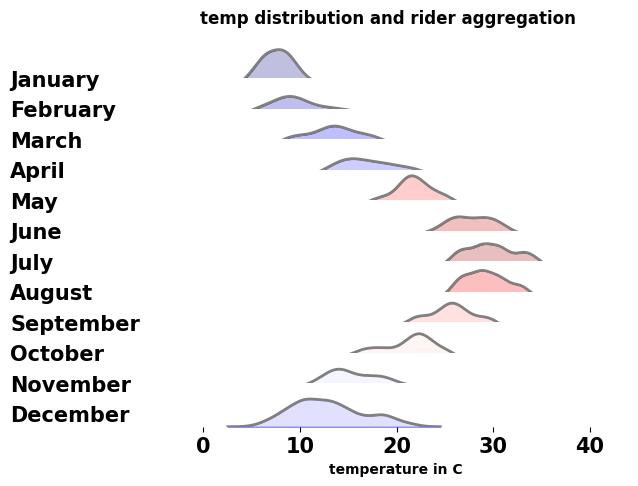

In [15]:
#generating a color palette with seaborn
pal = sns.color_palette(palette='seismic', n_colors=12)

#in the sns.FacetGrid class, the 'hue' argument is the on tthat is the one that 
g = sns.FacetGrid(df, row='month', aspect=15, height=0.4, hue='mean_month', palette=pal)

#adding k densities for each onth
g.map(sns.kdeplot, 'temp', fill=True, lw=1)

#adding a linear graph for the outline
g.map(sns.kdeplot, 'temp', lw=2, color='grey')

#using the fact grid axes and adding month as text with the right
for i, ax in enumerate(g.axes.flat):
    ax.text(-20, 0.02, month_dict[i+1],
            fontweight='bold', fontsize=15)

#adjusting the plots so they overlap
g.fig.subplots_adjust(hspace=-0.3)

#removing axes titles, yticks and spines
g.set_titles ("")
g.set(yticks=[])
g.despine(bottom=True, left=True)
g.set_ylabels("")
g.set_xlabels("")
plt.setp(ax.get_xticklabels(), fontsize=15, fontweight='bold')
plt.xlabel('temperature in C', fontweight='bold', fontsize=10)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('temp distribution and rider aggregation', fontweight='bold')

         

# Evaluating correlation

In [16]:
correlations = []
def correlation_matrix(data, col1, col2, col3, col4):
    correlation1_sp=spearmanr(data[col1], data[col2])[0]
    correlation2_sp=spearmanr(data[col3], data[col4])[0]
    correlation3_sp=pearsonr(data[col1], data[col2])[0]
    correlation4_sp=pearsonr(data[col3], data[col4])[0]
    series=pd.Series({'registered (spearman)':correlation1_sp,
                      'casual (spearman)':correlation2_sp,
                      'registered (pearson)':correlation3_sp,
                      'casual (pearson)':correlation4_sp})
    return series
correlation_matrix(df, 'registered', 'temp', 'casual', 'temp')

registered (spearman)    0.392768
casual (spearman)        0.608138
registered (pearson)     0.370767
casual (pearson)         0.498356
dtype: float64

<Axes: >

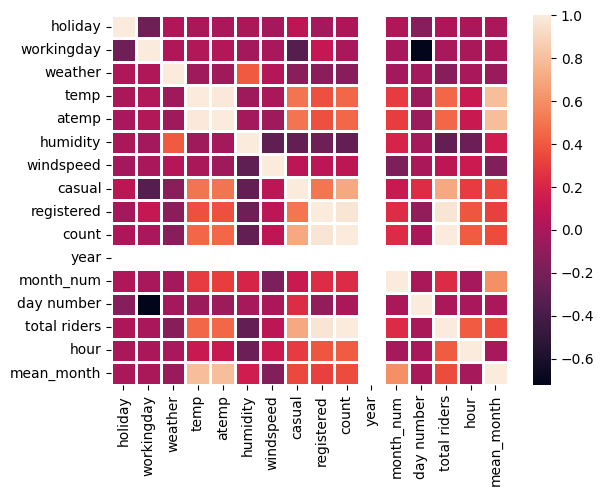

In [17]:
#creating a correlation plot
sns.heatmap(df.corr(numeric_only=True), linewidths=1)

Text(0.5, 1.0, 'overall correlation')

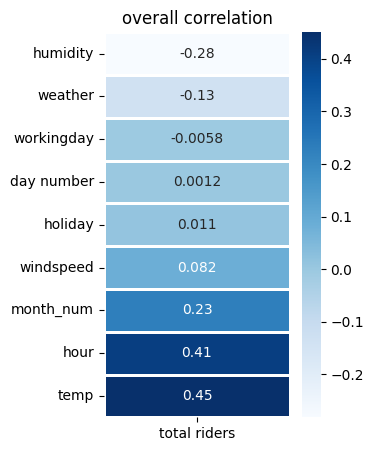

In [18]:
#isolating correlation the riders only
plt.figure(figsize=(3,5))
sns.heatmap(df.corr(numeric_only=True)[['total riders']].sort_values(by='total riders')\
    .drop(['total riders',
          'count',
          'mean_month',
          'atemp',
          'registered',
          'casual',
          'year']), linewidths=1, annot=True, cmap='Blues')
plt.title('overall correlation')

Text(0.5, 1.0, 'registered')

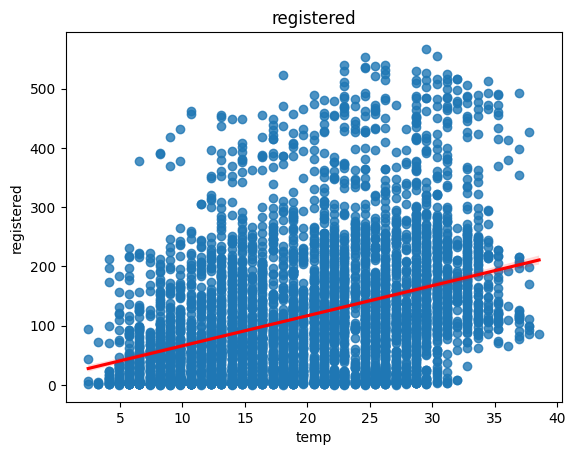

In [19]:
#creating a scatter plot with both rider types

r_corr=round(pearsonr(df['temp'], df['registered'])[0],2)
sns.regplot(data=df, x='temp', y='registered', line_kws={'color': 'red'},
            label=f' registered correlation {r_corr}')
plt.title('registered')

Text(0.5, 1.0, 'casual')

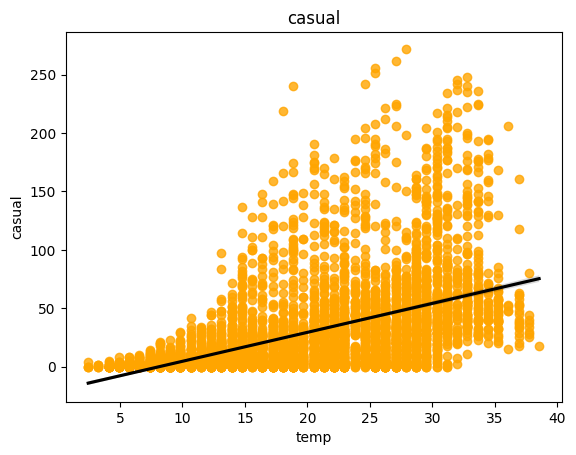

In [20]:
c_corr=round(pearsonr(df['temp'], df['casual'],) [0], 2)
sns.regplot(data=df, x='temp', y='casual', line_kws={'color': 'black'}, color='orange',
            label=f' registered correlation {c_corr}')
plt.title('casual')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0.5, 0, 'January'),
  Text(1.5, 0, 'February'),
  Text(2.5, 0, 'March'),
  Text(3.5, 0, 'April'),
  Text(4.5, 0, 'May'),
  Text(5.5, 0, 'June'),
  Text(6.5, 0, 'July'),
  Text(7.5, 0, 'August'),
  Text(8.5, 0, 'September'),
  Text(9.5, 0, 'October'),
  Text(10.5, 0, 'November'),
  Text(11.5, 0, 'December')])

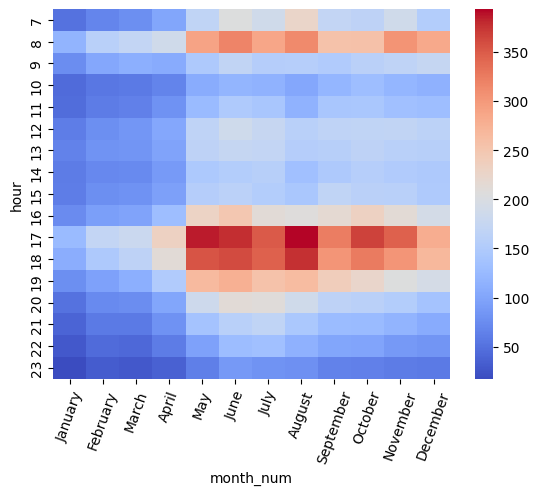

In [21]:
#creating a heatmap of hour and months 
ax = sns.heatmap(pd.pivot_table(data=df[df['hour']>6],
    index='hour',
    columns='month_num',
    values='registered',
    aggfunc='mean'), cmap='coolwarm')

ax.set_xticklabels(df.month.unique())
plt.xticks(rotation=70)

Text(0.5, 1.0, 'distribution of riders by day')

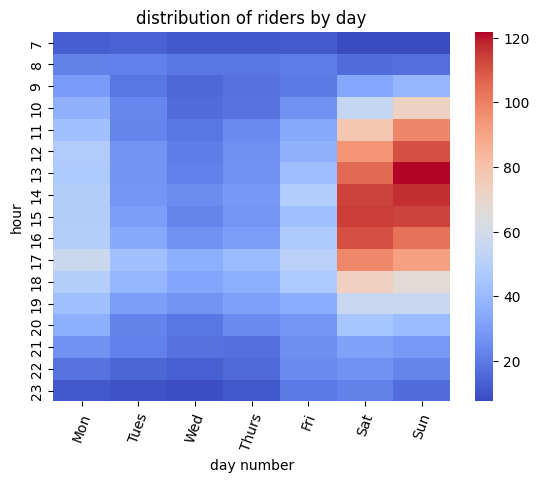

In [22]:
#creating a heatmap of hour and day
ax = sns.heatmap(pd.pivot_table(data=df[df['hour']>6],
    index='hour',
    columns='day number',
    values='casual',
    aggfunc='mean'), cmap='coolwarm')

ax.set_xticklabels(['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun'])
plt.xticks(rotation=70)
plt.title('distribution of riders by day')

In [24]:
#validation
df.groupby('day of week')['casual'].sum()/df['casual'].sum()*100

day of week
Friday       12.288133
Monday       13.505587
Saturday     24.625683
Sunday       24.204034
Thursday      8.612026
Tuesday       9.328892
Wednesday     7.435646
Name: casual, dtype: float64

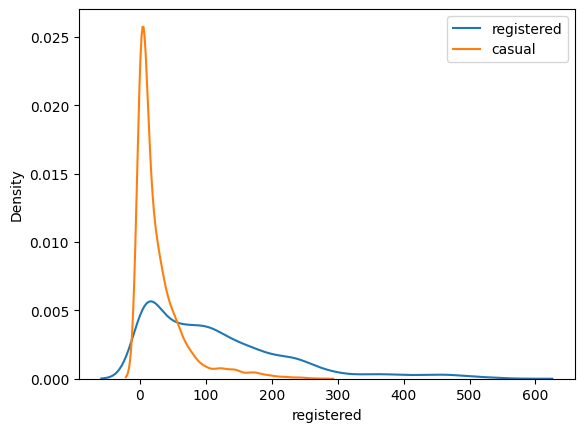

In [25]:
sns.kdeplot(df['registered'], label='registered')
sns.kdeplot(df['casual'], label='casual')
plt.legend()

In [28]:
df['temp buckets'] = pd.qcut(df['temp'], 4)

In [29]:
df['temp buckets'].value_counts()

temp buckets
(19.68, 26.24]    1412
(2.459, 13.12]    1395
(13.12, 19.68]    1344
(26.24, 38.54]    1271
Name: count, dtype: int64

In [31]:
grouping = df.groupby('temp buckets').mean(numeric_only=True)[['casual', 'registered', 'total riders']]
grouping ['difference'] = grouping ['registered']/grouping['casual']
grouping

,casual,registered,total riders,difference
temp buckets,,,,
"(2.459, 13.12]",5.572043,66.151254,71.723297,11.871993
"(13.12, 19.68]",20.004464,98.537946,118.542411,4.925798
"(19.68, 26.24]",32.763456,130.558074,163.321530,3.984869
"(26.24, 38.54]",58.926829,170.808812,229.735641,2.898659


<Axes: title={'center': 'exponential change in riders by temp group'}, xlabel='temp buckets', ylabel='difference'>

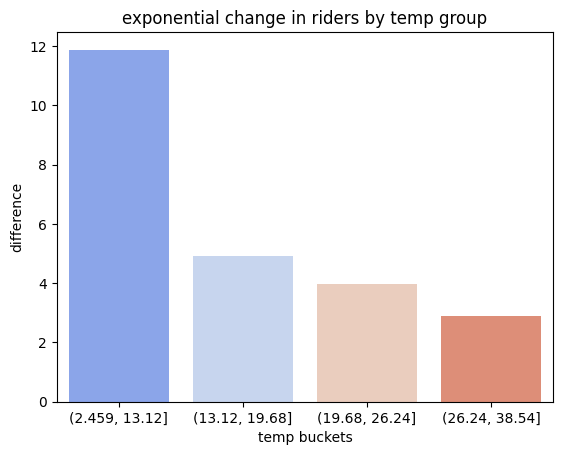

In [32]:
plt.title('exponential change in riders by temp group')
sns.barplot(data = grouping, x=grouping.index,
            y='difference', palette='coolwarm')